3 Hausübung, Kraftwerkseinsatzplanung, Gruppe 4

-----------------------------------------------------------------
Stunde     | Schattenvariable (c)      | Strompreis [€/MWh] (d)
-----------------------------------------------------------------
00:00 - 01:00 |                    105.37 |               105.37
01:00 - 02:00 |                    105.37 |               105.37
02:00 - 03:00 |                    105.37 |               105.37
03:00 - 04:00 |                    105.37 |               105.37
04:00 - 05:00 |                    105.37 |               105.37
05:00 - 06:00 |                    105.37 |               105.37
06:00 - 07:00 |                    105.37 |               105.37
07:00 - 08:00 |                    105.37 |               105.37
08:00 - 09:00 |                    105.37 |               105.37
09:00 - 10:00 |                    105.37 |               105.37
10:00 - 11:00 |                    148.50 |               148.50
11:00 - 12:00 |                    148.50 |               148.50
12:00 - 13:00 |         

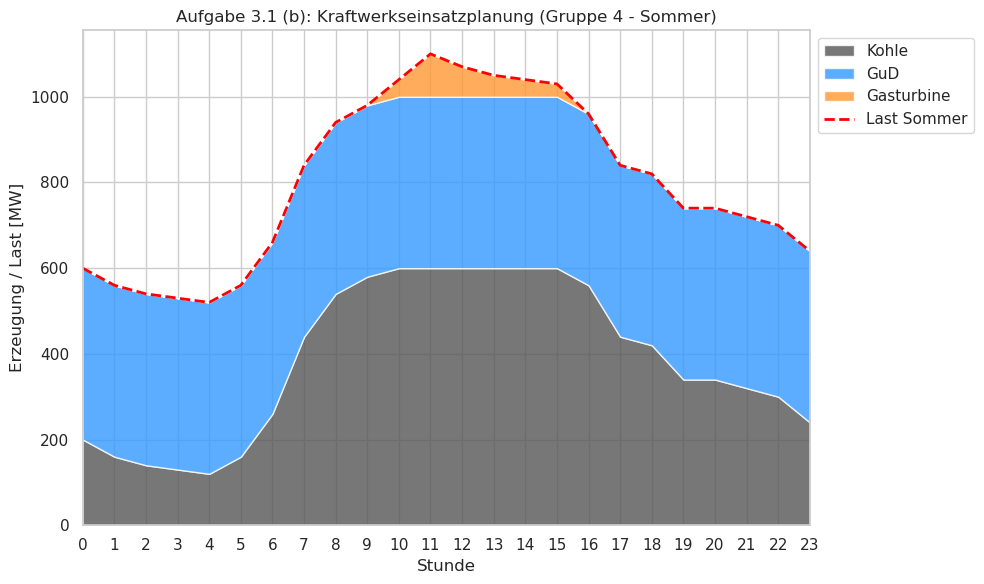

In [16]:
from pyomo.environ import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# falls nicht vorhanden müsst ihr noch den Solver installieren. Den Solver aus der Angabe hab ich nicht zum Laufen gebracht.
# !pip install highspy

# 1. Daten aus der Angabe für Gruppe 4 
T = 24
timesteps = np.arange(T)

c_CO2 = 72  # EUR/tCO2 (aus der neuen Angabe)

thermalPlant = ['Kohle', 'GuD', 'Gasturbine']
power = {'Kohle': 600, 'GuD': 400, 'Gasturbine': 300} # MW
efficiency = {'Kohle': 0.41, 'GuD': 0.58, 'Gasturbine': 0.4} 

# Brennstoffpreise (EUR/MWh_prim)
fuel_price = {'Kohle': 18, 'GuD': 45, 'Gasturbine': 45} 
# Emissionsfaktoren (tCO2/MWh_prim)
emission_factor = {'Kohle': 0.35, 'GuD': 0.2, 'Gasturbine': 0.2} 

# Berechnung der Grenzkosten (MC) und Emissionsfaktoren pro MWh_el
MC = {} 
emissions_per_mwh = {} 
for n in thermalPlant:
    # Formel: (Brennstoffpreis + CO2-Faktor * CO2-Preis) / Wirkungsgrad
    MC[n] = (fuel_price[n] + emission_factor[n] * c_CO2) / efficiency[n]
    emissions_per_mwh[n] = emission_factor[n] / efficiency[n]

# 2. Daten laden ("Last Sommer") das Excel muss im selben Ordner sein wie das Notebook!
df = pd.read_excel('Last_PV_Wind.xlsx')
load = df['Last Sommer [MW]'] 

# 3. Pyomo Modell aufstellen
model = ConcreteModel()

# Schattenvariablen (Dualwerte) aktivieren für Aufgabenteil c) und d)
model.dual = Suffix(direction=Suffix.IMPORT)

model.x = Var(thermalPlant, timesteps, within=NonNegativeReals)

# Zielfunktion: Gesamtkosten minimieren
def objective_rule(model):
    return sum(model.x[n, t] * MC[n] for n in thermalPlant for t in timesteps)
model.obj = Objective(rule=objective_rule, sense=minimize)

# Nebenbedingung 1: Maximale Kraftwerksleistung
def power_constraint_rule(model, n, t):    
   return model.x[n, t] <= power[n]
model.power_con = Constraint(thermalPlant, timesteps, rule=power_constraint_rule)

# Nebenbedingung 2: Lastdeckung (ohne EE und Speicher laut 3.1a)
def load_constraint_rule(model, t):    
   return sum(model.x[n, t] for n in thermalPlant) == load.loc[t]
model.load_con = Constraint(timesteps, rule=load_constraint_rule)

# 4. Optimierung
opt = SolverFactory('appsi_highs')
results = opt.solve(model)

# 5. Ausgabe für Aufgabe 3.1 c) und d)
print("-" * 65)
print(f"{'Stunde':<10} | {'Schattenvariable (c)':<25} | {'Strompreis [€/MWh] (d)':<20}")
print("-" * 65)

stunden_liste = []
schattenvariablen_liste = []

for t in timesteps:
    # Wert der Schattenvariable extrahieren
    val = model.dual[model.load_con[t]]
    stunden_liste.append(t)
    schattenvariablen_liste.append(val)
    
    print(f"{t:02d}:00 - {t+1:02d}:00 | {val:25.2f} | {val:20.2f}")

print("-" * 65)

# Zusätzliche Info für die Interpretation (Aufgabe c):
print("\nInterpretation für Aufgabenteil c):")
print("Die Schattenvariable gibt an, um wie viele EUR sich die Zielfunktion (Gesamtkosten)")
print("erhöhen würde, wenn die Last in dieser Stunde um 1 MW steigen würde.")
print("Sie entspricht den Grenzkosten des teuersten Kraftwerks, das in dieser Stunde")
print("gerade noch zur Deckung der Last benötigt wird (Grenzkraftwerk).")

# 6. Gesamtkosten und Emissionen (Aufgabe 3.1 a)
total_costs = model.obj()
total_emissions = sum(model.x[n, t].value * emissions_per_mwh[n] for n in thermalPlant for t in timesteps)

print("-" * 65)
print(f"Aufgabenteil a)")
print(f"Gesamtkosten: {total_costs:,.2f} EUR")
print(f"Gesamt-Emissionen: {total_emissions:,.2f} tCO2")
print("-" * 65)

# 7. Plotting (Aufgabe 3.1 b)
PowerThermal = pd.DataFrame(index=timesteps, columns=thermalPlant)
for t in timesteps:
    for n in thermalPlant:
        PowerThermal.loc[t, n] = model.x[n, t].value

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

ax.stackplot(timesteps, 
             PowerThermal.to_numpy(dtype=float).transpose(), 
             labels=thermalPlant,
             colors=['#555555', '#3399FF', '#FF9933'],
             alpha=0.8)

ax.plot(timesteps, load, color='red', linestyle='--', linewidth=2, label='Last Sommer')

ax.set_title('Aufgabe 3.1 (b): Kraftwerkseinsatzplanung (Gruppe 4 - Sommer)')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.set_ylabel('Erzeugung / Last [MW]')
ax.set_xlabel('Stunde')
ax.set_xticks(timesteps)
ax.set_xlim(0, 23)
fig.tight_layout()
plt.show()